# AAI 501 Final Team Project

## Intelligent Predictive Maintenance for Turbofan Engines Using Remaining Useful Life Prediction

**Team 6:** Sudhakaran Srinivasan, Mina Habib, Ivan Da Silva, Russell Miller

**Dataset:** NASA C-MAPSS — FD001  
**Primary target:** Remaining Useful Life (RUL)

### End-to-end workflow
1. Data preparation and RUL construction
2. EDA and degradation analysis
3. Baseline machine-learning models
4. XGBoost and explainability
5. LSTM sequence modeling
6. Integrated model comparison
7. PEAS-based intelligent maintenance decision agent
8. Capacity-constrained maintenance queue and policy evaluation

Run the notebook from top to bottom. Place `CMAPSSData.zip` in the project root,
`data/raw/`, or `/mnt/data/CMAPSSData.zip`.

## Executive Summary

This project predicts Remaining Useful Life from multivariate turbofan-engine sensor data
and converts the selected model's predictions into a capacity-constrained maintenance queue.
Its differentiator is a classical utility-based decision agent framed using the PEAS methodology.

# Part 1 — Data Preparation, EDA, and Degradation Analysis

In [33]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42
RUL_CAP = 125

## 1. Project paths and dataset extraction

In [34]:
from pathlib import Path

project = Path.home() / "Documents" / "GitHub" / "intelligent-predictive-maintenance"

print(project.exists())
print(project)

DATA_DIR = project / "datasets" / "raw" / "CMAPSSData"

print(DATA_DIR)
print(DATA_DIR.exists())

True
/Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance
/Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/raw/CMAPSSData
True


## 2. Load FD001 and assign column names

In [35]:
columns = (
    ["unit_id","cycle","setting_1","setting_2","setting_3"]
    + [f"sensor_{i}" for i in range(1,22)]
)

train = pd.read_csv(
    DATA_DIR / "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test = pd.read_csv(
    DATA_DIR / "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_rul = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul_at_last_observation"]
)

test_rul["unit_id"] = np.arange(1, len(test_rul) + 1)

In [36]:

display(train.head())
display(test.head())
display(test_rul.head())

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,rul_at_last_observation,unit_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


## 3. Data-quality checks

In [37]:
quality_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_train": train.isna().sum(),
    "missing_test": test.isna().sum(),
    "nunique_train": train.nunique(),
    "variance_train": train.var(numeric_only=True)
})

print("Duplicate training rows:", train.duplicated().sum())
print("Duplicate test rows:", test.duplicated().sum())
print("Training engines:", train["unit_id"].nunique())
print("Test engines:", test["unit_id"].nunique())
display(quality_summary)


Duplicate training rows: 0
Duplicate test rows: 0
Training engines: 100
Test engines: 100


,dtype,missing_train,missing_test,nunique_train,variance_train
unit_id,int64,0,0,100,8.542545e+02
cycle,int64,0,0,362,4.744591e+03
setting_1,float64,0,0,158,4.784340e-06
setting_2,float64,0,0,13,8.588541e-08
setting_3,float64,0,0,1,0.000000e+00
sensor_1,float64,0,0,1,0.000000e+00
sensor_2,float64,0,0,310,2.500533e-01
sensor_3,float64,0,0,3012,3.759099e+01
sensor_4,float64,0,0,4051,8.101089e+01
sensor_5,float64,0,0,1,2.840037e-29


## 4. Construct Remaining Useful Life

For each training row:

\[
RUL = 	ext{maximum cycle for that engine} - 	ext{current cycle}
\]

We retain both the uncapped and capped targets. The capped target treats the early
healthy period as a plateau and is commonly used in C-MAPSS modeling.

In [38]:
RUL_CAP = 125

max_cycles = (
    train.groupby("unit_id")["cycle"]
    .max()
    .rename("max_cycle")
    .reset_index()
)

train = train.merge(max_cycles, on="unit_id", how="left")
train["rul"] = train["max_cycle"] - train["cycle"]
train["rul_capped"] = train["rul"].clip(upper=RUL_CAP)

# Ground truth for each test engine at its final observed cycle
test_last = (
    test.sort_values(["unit_id", "cycle"])
    .groupby("unit_id", as_index=False)
    .tail(1)
    .merge(test_rul, on="unit_id", how="left")
    .rename(columns={"rul_at_last_observation": "actual_rul"})
    .sort_values("unit_id")
    .reset_index(drop=True)
)

assert train["rul"].min() == 0
assert test_last["actual_rul"].notna().all()







In [39]:
display(train.head())
display(test.head())
display(test_last.head())
display(test_rul.head())

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,rul,rul_capped
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187,125


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,actual_rul
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,21.61,554.42,2388.08,9056.40,1.3,47.23,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552,112
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,21.61,553.52,2388.10,9044.77,1.3,47.67,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618,98
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,21.61,552.59,2388.16,9049.26,1.3,47.88,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740,69
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,21.61,552.64,2388.13,9051.30,1.3,47.65,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581,82
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,21.61,553.29,2388.10,9053.99,1.3,47.46,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117,91


,rul_at_last_observation,unit_id
0,112,1
1,98,2
2,69,3
3,82,4
4,91,5


In [40]:
print("Training engines:", train["unit_id"].nunique())
print("Test engines:", test_last["unit_id"].nunique())
print("Training RUL range:", train["rul"].min(), "to", train["rul"].max())
print("Capped RUL range:", train["rul_capped"].min(), "to", train["rul_capped"].max())
print("Test RUL range:", test_last["actual_rul"].min(), "to", test_last["actual_rul"].max())



Training engines: 100
Test engines: 100
Training RUL range: 0 to 361
Capped RUL range: 0 to 125
Test RUL range: 7 to 145


## 5. Engine-lifetime analysis

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


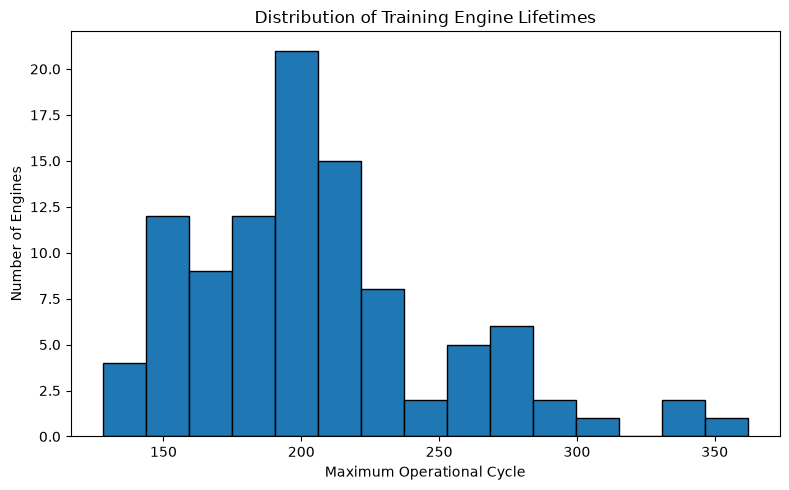

In [41]:
engine_life = train.groupby("unit_id")["cycle"].max()

print(engine_life.describe())

plt.figure(figsize=(8, 5))
plt.hist(engine_life, bins=15, edgecolor="black")
plt.title("Distribution of Training Engine Lifetimes")
plt.xlabel("Maximum Operational Cycle")
plt.ylabel("Number of Engines")
plt.tight_layout()
plt.show()

## 6. Identify low-variance sensors

In [42]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
setting_cols = ["setting_1", "setting_2", "setting_3"]

sensor_variance = train[sensor_cols].var().sort_values()
display(sensor_variance.to_frame("variance"))

VARIANCE_THRESHOLD = 1e-8
low_variance_sensors = sensor_variance[
    sensor_variance <= VARIANCE_THRESHOLD
].index.tolist()

selected_sensors = [s for s in sensor_cols if s not in low_variance_sensors]

print("Low-variance sensors removed:", low_variance_sensors)
print("Selected sensors:", selected_sensors)

,variance
sensor_1,0.000000e+00
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_10,0.000000e+00
sensor_16,1.203765e-35
sensor_5,2.840037e-29
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


Low-variance sensors removed: ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5']
Selected sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


## 7. Correlation with cycle and RUL

In [43]:
correlation_table = pd.DataFrame({
    "corr_with_cycle": train[selected_sensors].corrwith(train["cycle"]),
    "corr_with_rul": train[selected_sensors].corrwith(train["rul_capped"])
}).sort_values("corr_with_rul", key=lambda s: s.abs(), ascending=False)

display(correlation_table)

,corr_with_cycle,corr_with_rul
sensor_11,0.634385,-0.775230
sensor_4,0.624577,-0.757157
sensor_12,-0.611354,0.748870
sensor_7,-0.595914,0.733021
sensor_15,0.588676,-0.720858
sensor_21,-0.585923,0.707334
sensor_20,-0.583597,0.704626
sensor_17,0.566995,-0.680829
sensor_2,0.549898,-0.678458
sensor_3,0.543947,-0.655030


## 8. Plot representative degradation trajectories

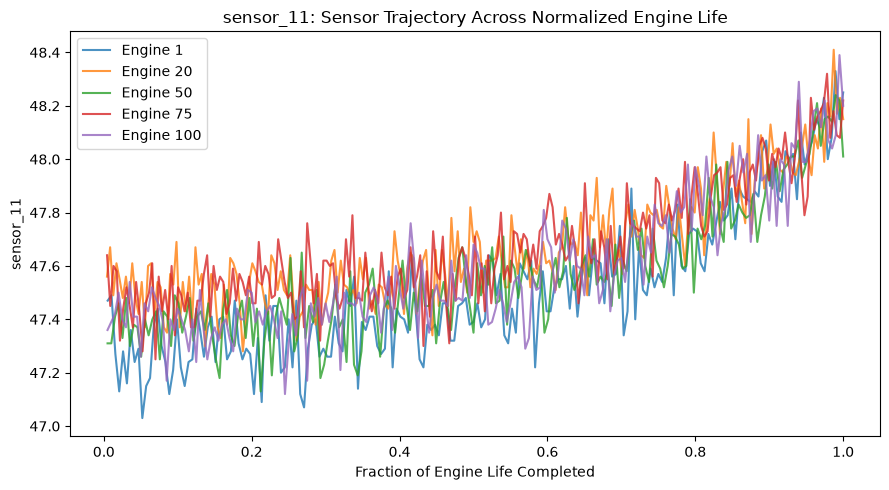

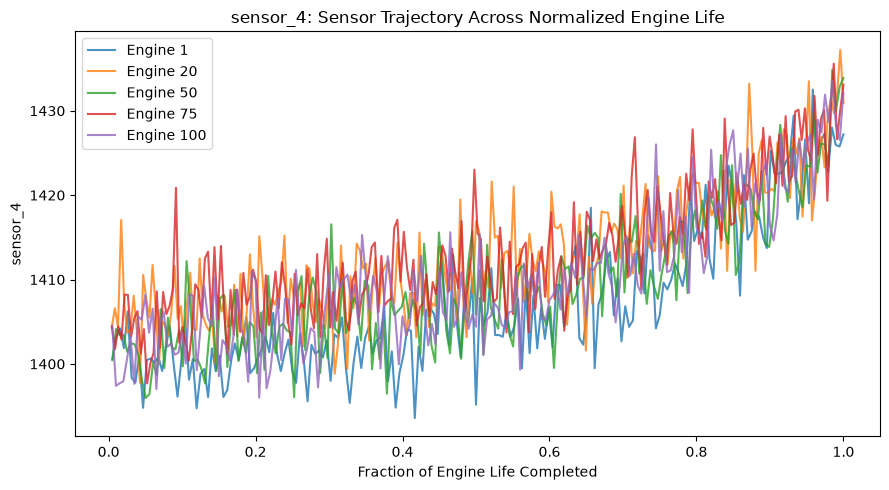

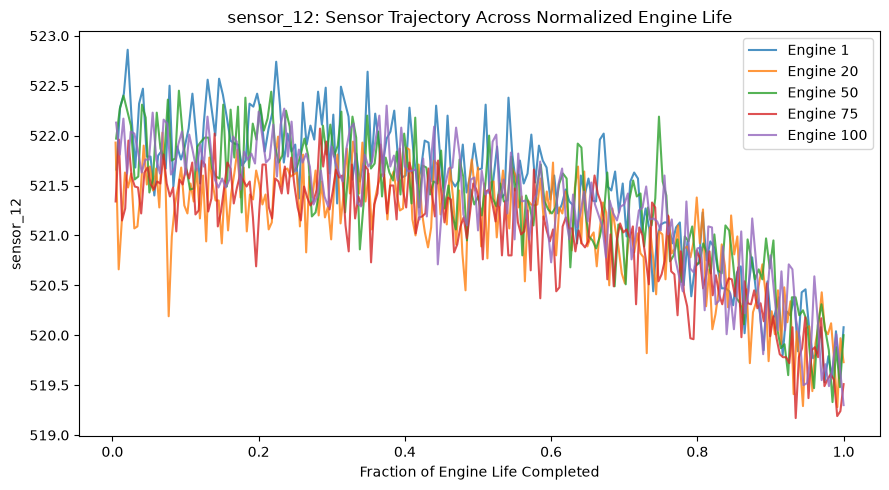

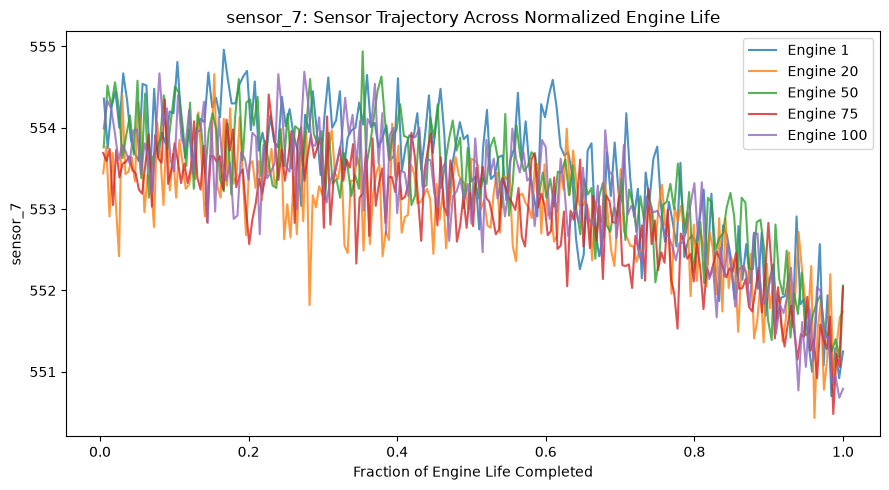

In [44]:
top_sensors = correlation_table.head(6).index.tolist()
example_engines = [1, 20, 50, 75, 100]

for sensor in top_sensors[:4]:
    plt.figure(figsize=(9, 5))
    for engine_id in example_engines:
        engine = train[train["unit_id"] == engine_id]
        life_fraction = engine["cycle"] / engine["max_cycle"]
        plt.plot(life_fraction, engine[sensor], label=f"Engine {engine_id}", alpha=0.8)

    plt.title(f"{sensor}: Sensor Trajectory Across Normalized Engine Life")
    plt.xlabel("Fraction of Engine Life Completed")
    plt.ylabel(sensor)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 9. Compare early-, middle-, and late-life sensor behavior

life_stage,Late life (RUL ≤ 30),Middle life,Early life
sensor_11,47.963948,47.591160,47.383485
sensor_4,1422.811913,1410.588063,1403.748882
sensor_12,520.290668,521.279459,521.833066
sensor_7,552.050997,553.206069,553.862756
sensor_15,8.497328,8.448600,8.421611
sensor_21,23.133585,23.271273,23.347914


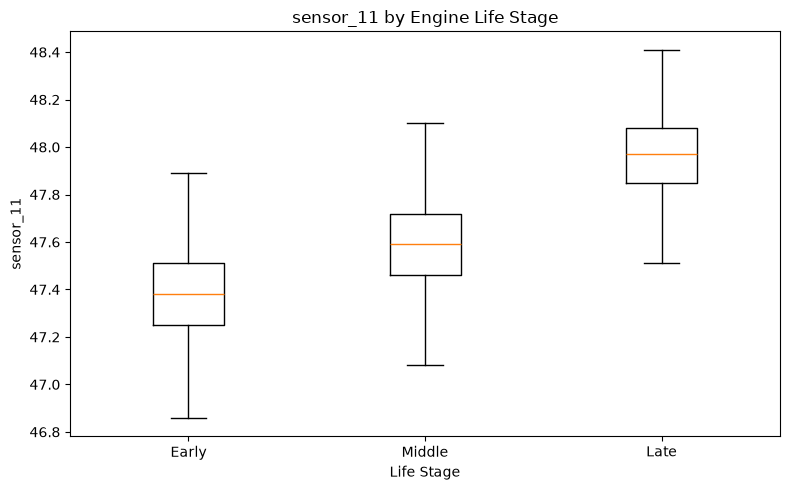

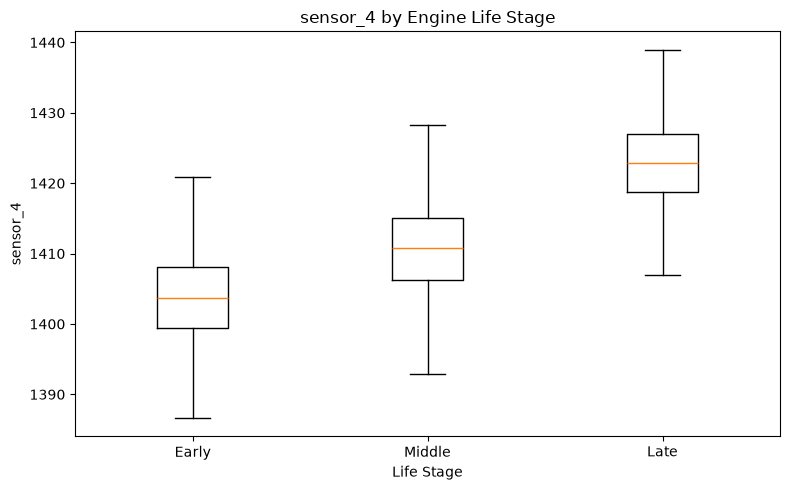

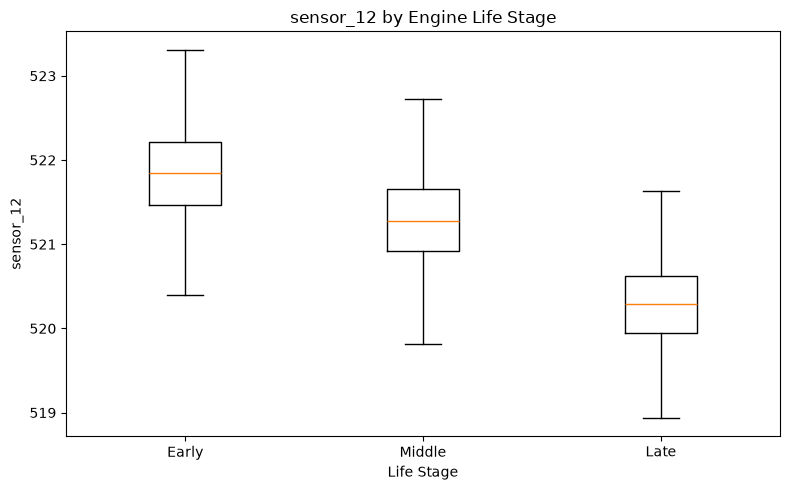

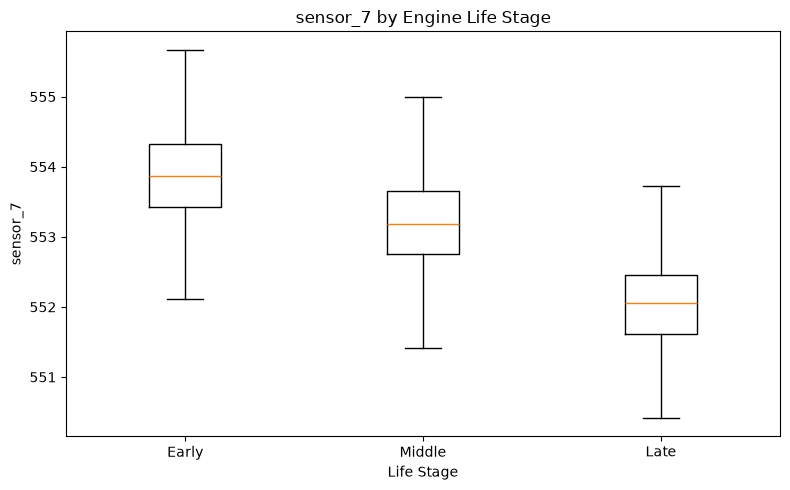

In [45]:
train["life_stage"] = pd.cut(
    train["rul"],
    bins=[-1, 30, 100, np.inf],
    labels=["Late life (RUL ≤ 30)", "Middle life", "Early life"]
)

stage_summary = (
    train.groupby("life_stage", observed=False)[top_sensors]
    .mean()
    .T
)
display(stage_summary)

for sensor in top_sensors[:4]:
    data = [
        train.loc[train["life_stage"] == stage, sensor].dropna()
        for stage in ["Early life", "Middle life", "Late life (RUL ≤ 30)"]
    ]
    plt.figure(figsize=(8, 5))
    plt.boxplot(data, tick_labels=["Early", "Middle", "Late"], showfliers=False)
    plt.title(f"{sensor} by Engine Life Stage")
    plt.xlabel("Life Stage")
    plt.ylabel(sensor)
    plt.tight_layout()
    plt.show()

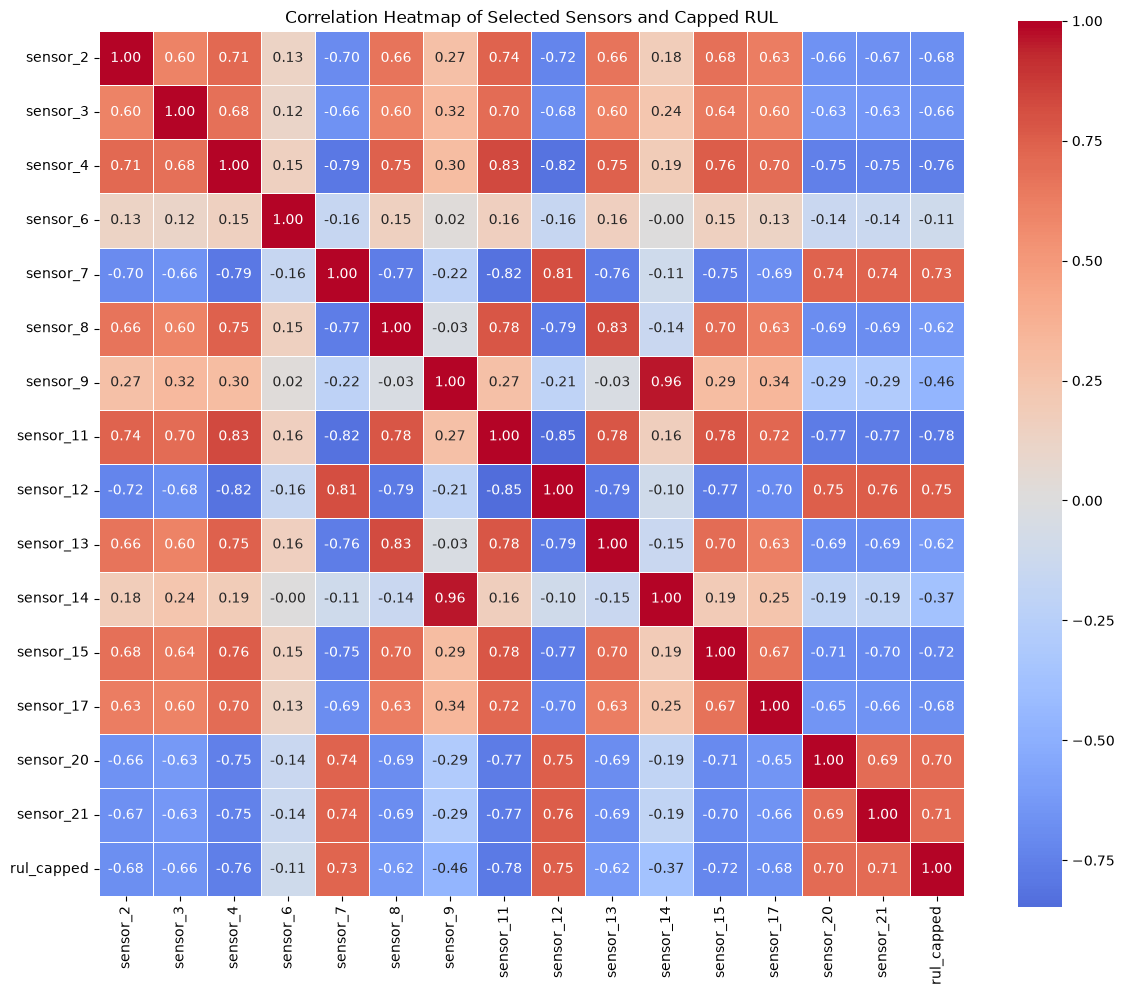

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = train[selected_sensors + ["rul_capped"]].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Sensors and Capped RUL")
plt.tight_layout()
plt.show()

## 10. Create leakage-safe rolling features

Rolling features are calculated separately within each engine and use only the
current and previous cycles. This avoids using future observations.

In [47]:
def add_rolling_features(df, sensors, windows=(5, 10)):
    result = df.sort_values(["unit_id", "cycle"]).copy()
    grouped = result.groupby("unit_id", group_keys=False)

    for sensor in sensors:
        result[f"{sensor}_diff_1"] = grouped[sensor].diff().fillna(0)

        for window in windows:
            result[f"{sensor}_roll_mean_{window}"] = (
                grouped[sensor]
                .rolling(window, min_periods=1)
                .mean()
                .reset_index(level=0, drop=True)
            )
            result[f"{sensor}_roll_std_{window}"] = (
                grouped[sensor]
                .rolling(window, min_periods=2)
                .std()
                .reset_index(level=0, drop=True)
                .fillna(0)
            )

    return result

# Limit engineered features to the six most RUL-correlated sensors
engineered_sensors = top_sensors[:6]

train_features = add_rolling_features(train, engineered_sensors)
test_features = add_rolling_features(test, engineered_sensors)

print("Engineered sensors:", engineered_sensors)
print("Train feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)

Engineered sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21']
Train feature shape: (20631, 60)
Test feature shape: (13096, 56)


In [48]:
display(train_features.head())
display(test_features.head())


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,...,sensor_4_diff_1,sensor_4_roll_mean_5,sensor_4_roll_std_5,sensor_4_roll_mean_10,sensor_4_roll_std_10,sensor_12_diff_1,sensor_12_roll_mean_5,sensor_12_roll_std_5,sensor_12_roll_mean_10,sensor_12_roll_std_10,sensor_7_diff_1,sensor_7_roll_mean_5,sensor_7_roll_std_5,sensor_7_roll_mean_10,sensor_7_roll_std_10,sensor_15_diff_1,sensor_15_roll_mean_5,sensor_15_roll_std_5,sensor_15_roll_mean_10,sensor_15_roll_std_10,sensor_21_diff_1,sensor_21_roll_mean_5,sensor_21_roll_std_5,sensor_21_roll_mean_10,sensor_21_roll_std_10
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,...,0.00,1400.600000,0.000000,1400.600000,0.000000,0.00,521.660,0.000000,521.660,0.000000,0.00,554.360000,0.000000,554.360000,0.000000,0.0000,8.419500,0.000000,8.419500,0.000000,0.0000,23.419000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,...,2.54,1401.870000,1.796051,1401.870000,1.796051,0.62,521.970,0.438406,521.970,0.438406,-0.61,554.055000,0.431335,554.055000,0.431335,0.0123,8.425650,0.008697,8.425650,0.008697,0.0046,23.421300,0.003253,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,...,1.06,1402.646667,1.850009,1402.646667,1.850009,0.14,522.120,0.404475,522.120,0.404475,0.51,554.123333,0.327159,554.123333,0.327159,-0.0140,8.423033,0.007640,8.423033,0.007640,-0.0794,23.395600,0.044573,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,...,-2.33,1402.452500,1.559645,1402.452500,1.559645,0.44,522.305,0.495950,522.305,0.495950,0.19,554.205000,0.313103,554.205000,0.313103,-0.0496,8.409325,0.028117,8.409325,0.028117,0.0297,23.390175,0.037977,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,...,4.35,1403.206000,2.159440,1403.206000,2.159440,-0.67,522.282,0.432574,522.282,0.432574,-0.45,554.164000,0.286234,554.164000,0.286234,0.0612,8.413340,0.025953,8.413340,0.025953,0.0305,23.393020,0.033498,23.393020,0.033498


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,...,sensor_4_diff_1,sensor_4_roll_mean_5,sensor_4_roll_std_5,sensor_4_roll_mean_10,sensor_4_roll_std_10,sensor_12_diff_1,sensor_12_roll_mean_5,sensor_12_roll_std_5,sensor_12_roll_mean_10,sensor_12_roll_std_10,sensor_7_diff_1,sensor_7_roll_mean_5,sensor_7_roll_std_5,sensor_7_roll_mean_10,sensor_7_roll_std_10,sensor_15_diff_1,sensor_15_roll_mean_5,sensor_15_roll_std_5,sensor_15_roll_mean_10,sensor_15_roll_std_10,sensor_21_diff_1,sensor_21_roll_mean_5,sensor_21_roll_std_5,sensor_21_roll_mean_10,sensor_21_roll_std_10
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,...,0.00,1398.210000,0.000000,1398.210000,0.000000,0.00,521.7200,0.000000,521.7200,0.000000,0.00,553.900000,0.000000,553.900000,0.000000,0.0000,8.405200,0.000000,8.405200,0.000000,0.0000,23.37350,0.000000,23.37350,0.000000
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,...,-2.79,1396.815000,1.972828,1396.815000,1.972828,0.44,521.9400,0.311127,521.9400,0.311127,0.95,554.375000,0.671751,554.375000,0.671751,-0.0249,8.392750,0.017607,8.392750,0.017607,0.0181,23.38255,0.012799,23.38255,0.012799
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,...,5.92,1398.323333,2.961627,1398.323333,2.961627,-0.19,521.9500,0.220681,521.9500,0.220681,-0.74,554.286667,0.499032,554.286667,0.499032,0.0638,8.409867,0.032155,8.409867,0.032155,0.0250,23.39390,0.021642,23.39390,0.021642
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,...,5.08,1400.347500,4.715558,1400.347500,4.715558,-0.59,521.8075,0.337182,521.8075,0.337182,-0.04,554.232500,0.421614,554.232500,0.421614,-0.0524,8.405325,0.027781,8.405325,0.027781,-0.0429,23.38885,0.020353,23.38885,0.020353
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,...,-4.50,1400.662000,4.143902,1400.662000,4.143902,0.77,521.8760,0.329742,521.8760,0.329742,0.09,554.218000,0.366565,554.218000,0.366565,0.0114,8.404880,0.024080,8.404880,0.024080,0.0393,23.39368,0.020672,23.39368,0.020672


## 11. Save processed datasets and metadata

In [49]:
from pathlib import Path

PROJECT_ROOT = (
    Path.home()
    / "Documents"
    / "GitHub"
    / "intelligent-predictive-maintenance"
)

PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(PROCESSED_DIR)

/Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/processed


In [50]:
train_features.to_csv(PROCESSED_DIR / "fd001_train_processed.csv", index=False)
test_features.to_csv(PROCESSED_DIR / "fd001_test_processed.csv", index=False)
test_last.to_csv(PROCESSED_DIR / "fd001_test_last_with_rul.csv", index=False)

metadata = {
    "rul_cap": RUL_CAP,
    "selected_sensors": selected_sensors,
    "engineered_sensors": engineered_sensors,
    "low_variance_sensors": low_variance_sensors,
    "train_rows": int(len(train_features)),
    "test_rows": int(len(test_features)),
    "train_engines": int(train_features["unit_id"].nunique()),
    "test_engines": int(test_features["unit_id"].nunique())
}

import json
with open(PROCESSED_DIR / "fd001_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved processed files to:", PROCESSED_DIR)
print(json.dumps(metadata, indent=2))

Saved processed files to: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/processed
{
  "rul_cap": 125,
  "selected_sensors": [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_17",
    "sensor_20",
    "sensor_21"
  ],
  "engineered_sensors": [
    "sensor_11",
    "sensor_4",
    "sensor_12",
    "sensor_7",
    "sensor_15",
    "sensor_21"
  ],
  "low_variance_sensors": [
    "sensor_1",
    "sensor_19",
    "sensor_18",
    "sensor_10",
    "sensor_16",
    "sensor_5"
  ],
  "train_rows": 20631,
  "test_rows": 13096,
  "train_engines": 100,
  "test_engines": 100
}


## Notebook 01 conclusions

Complete this Markdown cell after running the notebook:

- FD001 contains ___ training rows and ___ test rows.
- The training set contains ___ engines.
- The most informative sensors by absolute RUL correlation were ___.
- The following sensors were removed because they were nearly constant: ___.
- The degradation plots indicate that ___.

# Part 2 — Baseline Machine-Learning Models

In [51]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

RANDOM_STATE = 42

In [52]:
from pathlib import Path
import json
import pandas as pd

# ---------------------------------------------------------
# 1. Define the GitHub project root
# ---------------------------------------------------------
PROJECT_ROOT = (
    Path.home()
    / "Documents"
    / "GitHub"
    / "intelligent-predictive-maintenance"
)

# ---------------------------------------------------------
# 2. Define project folders
# ---------------------------------------------------------
RAW_DIR = PROJECT_ROOT / "datasets" / "raw" / "CMAPSSData"
PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"
PREDICTIONS_DIR = PROJECT_ROOT / "datasets" / "predictions"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

# ---------------------------------------------------------
# 3. Create folders if they do not already exist
# ---------------------------------------------------------
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 4. Display paths for verification
# ---------------------------------------------------------
print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)
print("Predictions:", PREDICTIONS_DIR)
print("Figures:", FIGURES_DIR)

Project root: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance
Processed data: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/processed
Predictions: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/datasets/predictions
Figures: /Users/sudhakaransrinivasan/Documents/GitHub/intelligent-predictive-maintenance/outputs/figures


In [53]:
train = pd.read_csv(
    PROCESSED_DIR / "fd001_train_processed.csv"
)

test = pd.read_csv(
    PROCESSED_DIR / "fd001_test_processed.csv"
)

test_last_truth = pd.read_csv(
    PROCESSED_DIR / "fd001_test_last_with_rul.csv"
)

with open(
    PROCESSED_DIR / "fd001_metadata.json",
    "r"
) as file:
    metadata = json.load(file)

display(train.head())
display(test.head())
display(test_last_truth.head())

print(metadata)

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,...,sensor_4_diff_1,sensor_4_roll_mean_5,sensor_4_roll_std_5,sensor_4_roll_mean_10,sensor_4_roll_std_10,sensor_12_diff_1,sensor_12_roll_mean_5,sensor_12_roll_std_5,sensor_12_roll_mean_10,sensor_12_roll_std_10,sensor_7_diff_1,sensor_7_roll_mean_5,sensor_7_roll_std_5,sensor_7_roll_mean_10,sensor_7_roll_std_10,sensor_15_diff_1,sensor_15_roll_mean_5,sensor_15_roll_std_5,sensor_15_roll_mean_10,sensor_15_roll_std_10,sensor_21_diff_1,sensor_21_roll_mean_5,sensor_21_roll_std_5,sensor_21_roll_mean_10,sensor_21_roll_std_10
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,...,0.00,1400.600000,0.000000,1400.600000,0.000000,0.00,521.660,0.000000,521.660,0.000000,0.00,554.360000,0.000000,554.360000,0.000000,0.0000,8.419500,0.000000,8.419500,0.000000,0.0000,23.419000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,...,2.54,1401.870000,1.796051,1401.870000,1.796051,0.62,521.970,0.438406,521.970,0.438406,-0.61,554.055000,0.431335,554.055000,0.431335,0.0123,8.425650,0.008697,8.425650,0.008697,0.0046,23.421300,0.003253,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,...,1.06,1402.646667,1.850009,1402.646667,1.850009,0.14,522.120,0.404475,522.120,0.404475,0.51,554.123333,0.327159,554.123333,0.327159,-0.0140,8.423033,0.007640,8.423033,0.007640,-0.0794,23.395600,0.044573,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,...,-2.33,1402.452500,1.559645,1402.452500,1.559645,0.44,522.305,0.495950,522.305,0.495950,0.19,554.205000,0.313103,554.205000,0.313103,-0.0496,8.409325,0.028117,8.409325,0.028117,0.0297,23.390175,0.037977,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,...,4.35,1403.206000,2.159440,1403.206000,2.159440,-0.67,522.282,0.432574,522.282,0.432574,-0.45,554.164000,0.286234,554.164000,0.286234,0.0612,8.413340,0.025953,8.413340,0.025953,0.0305,23.393020,0.033498,23.393020,0.033498


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,...,sensor_4_diff_1,sensor_4_roll_mean_5,sensor_4_roll_std_5,sensor_4_roll_mean_10,sensor_4_roll_std_10,sensor_12_diff_1,sensor_12_roll_mean_5,sensor_12_roll_std_5,sensor_12_roll_mean_10,sensor_12_roll_std_10,sensor_7_diff_1,sensor_7_roll_mean_5,sensor_7_roll_std_5,sensor_7_roll_mean_10,sensor_7_roll_std_10,sensor_15_diff_1,sensor_15_roll_mean_5,sensor_15_roll_std_5,sensor_15_roll_mean_10,sensor_15_roll_std_10,sensor_21_diff_1,sensor_21_roll_mean_5,sensor_21_roll_std_5,sensor_21_roll_mean_10,sensor_21_roll_std_10
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,21.61,553.90,2388.04,9050.17,1.3,47.20,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,...,0.00,1398.210000,0.000000,1398.210000,0.000000,0.00,521.7200,0.000000,521.7200,0.000000,0.00,553.900000,0.000000,553.900000,0.000000,0.0000,8.405200,0.000000,8.405200,0.000000,0.0000,23.37350,0.000000,23.37350,0.000000
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,21.61,554.85,2388.01,9054.42,1.3,47.50,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,...,-2.79,1396.815000,1.972828,1396.815000,1.972828,0.44,521.9400,0.311127,521.9400,0.311127,0.95,554.375000,0.671751,554.375000,0.671751,-0.0249,8.392750,0.017607,8.392750,0.017607,0.0181,23.38255,0.012799,23.38255,0.012799
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,21.61,554.11,2388.05,9056.96,1.3,47.50,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,...,5.92,1398.323333,2.961627,1398.323333,2.961627,-0.19,521.9500,0.220681,521.9500,0.220681,-0.74,554.286667,0.499032,554.286667,0.499032,0.0638,8.409867,0.032155,8.409867,0.032155,0.0250,23.39390,0.021642,23.39390,0.021642
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,21.61,554.07,2388.03,9045.29,1.3,47.28,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,...,5.08,1400.347500,4.715558,1400.347500,4.715558,-0.59,521.8075,0.337182,521.8075,0.337182,-0.04,554.232500,0.421614,554.232500,0.421614,-0.0524,8.405325,0.027781,8.405325,0.027781,-0.0429,23.38885,0.020353,23.38885,0.020353
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,21.61,554.16,2388.01,9044.55,1.3,47.31,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,...,-4.50,1400.662000,4.143902,1400.662000,4.143902,0.77,521.8760,0.329742,521.8760,0.329742,0.09,554.218000,0.366565,554.218000,0.366565,0.0114,8.404880,0.024080,8.404880,0.024080,0.0393,23.39368,0.020672,23.39368,0.020672


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,actual_rul
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,21.61,554.42,2388.08,9056.40,1.3,47.23,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552,112
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,21.61,553.52,2388.10,9044.77,1.3,47.67,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618,98
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,21.61,552.59,2388.16,9049.26,1.3,47.88,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740,69
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,21.61,552.64,2388.13,9051.30,1.3,47.65,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581,82
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,21.61,553.29,2388.10,9053.99,1.3,47.46,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117,91


{'rul_cap': 125, 'selected_sensors': ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'], 'engineered_sensors': ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21'], 'low_variance_sensors': ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5'], 'train_rows': 20631, 'test_rows': 13096, 'train_engines': 100, 'test_engines': 100}


## 1. Define evaluation metrics

In [54]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def cmapss_score(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalties = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )
    return float(penalties.sum())

def evaluate_regression(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "rmse": rmse(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "cmapss_score": cmapss_score(y_true, y_pred)
    }

## 2. Select features and target

In [55]:
excluded = {
    "unit_id", "max_cycle", "rul", "rul_capped", "life_stage"
}

feature_cols = [
    c for c in train.columns
    if c not in excluded
]

target_col = "rul_capped"

print("Number of features:", len(feature_cols))
print(feature_cols[:20])

Number of features: 55
['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16']


## 3. Group-based train/validation split

In [56]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    splitter.split(
        train[feature_cols],
        train[target_col],
        groups=train["unit_id"]
    )
)

train_part = train.iloc[train_idx].copy()
val_part = train.iloc[val_idx].copy()

X_train = train_part[feature_cols]
y_train = train_part[target_col]
X_val = val_part[feature_cols]
y_val = val_part[target_col]

print("Training engines:", train_part["unit_id"].nunique())
print("Validation engines:", val_part["unit_id"].nunique())
print("Engine overlap:", set(train_part["unit_id"]) & set(val_part["unit_id"]))

Training engines: 80
Validation engines: 20
Engine overlap: set()


We considered cross-validation, but because observations within the same engine are highly correlated, ordinary K-Fold would introduce data leakage. The appropriate alternative would be GroupKFold using engine identifiers as groups. Given the computational cost of repeatedly training multiple machine learning and deep learning models, and the availability of an official NASA train/test split, we used a group-based holdout validation set while ensuring complete separation of engines between training and validation.

## 4. Mean-prediction baseline

In [57]:
mean_prediction = np.repeat(y_train.mean(), len(y_val))
baseline_result = evaluate_regression(y_val, mean_prediction, "Mean Baseline")
baseline_result

{'model': 'Mean Baseline',
 'rmse': 41.72082538935907,
 'mae': 36.929802663876686,
 'cmapss_score': 1285855.8101210925}

## 5. Linear Regression

In [58]:
# Linear Regression pipeline
linear_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Train
linear_pipeline.fit(X_train, y_train)

# Validation predictions
linear_val_pred = linear_pipeline.predict(X_val)

# Evaluate
linear_result = evaluate_regression(
    y_val,
    linear_val_pred,
    "Linear Regression"
)

linear_result

{'model': 'Linear Regression',
 'rmse': 17.62726557443863,
 'mae': 14.229014331844343,
 'cmapss_score': 21179.571561467248}

## 6. Ridge Regression

In [59]:
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_train, y_train)
ridge_val_pred = ridge_pipeline.predict(X_val)
ridge_result = evaluate_regression(y_val, ridge_val_pred, "Ridge Regression")
ridge_result

{'model': 'Ridge Regression',
 'rmse': 17.62007226304623,
 'mae': 14.228357089341019,
 'cmapss_score': 21123.002137115094}

## 7. Random Forest

In [60]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)
rf_result = evaluate_regression(y_val, rf_val_pred, "Random Forest")
rf_result

{'model': 'Random Forest',
 'rmse': 14.519380469097749,
 'mae': 10.09882350455788,
 'cmapss_score': 16570.677073888404}

## 7. Compare validation performance

In [61]:


comparison = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    rf_result
])

comparison.style.format({
    "rmse": "{:.2f}",
    "mae": "{:.2f}",
    "cmapss_score": "{:,.0f}"
})

,model,rmse,mae,cmapss_score
0,Mean Baseline,41.72,36.93,"1,285,856"
1,Linear Regression,17.63,14.23,"21,180"
2,Ridge Regression,17.62,14.23,"21,123"
3,Random Forest,14.52,10.10,"16,571"


## 8. Residual analysis

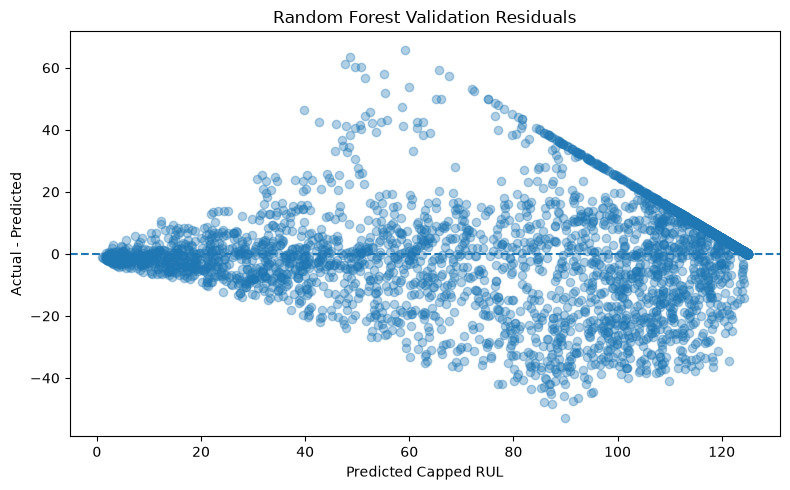

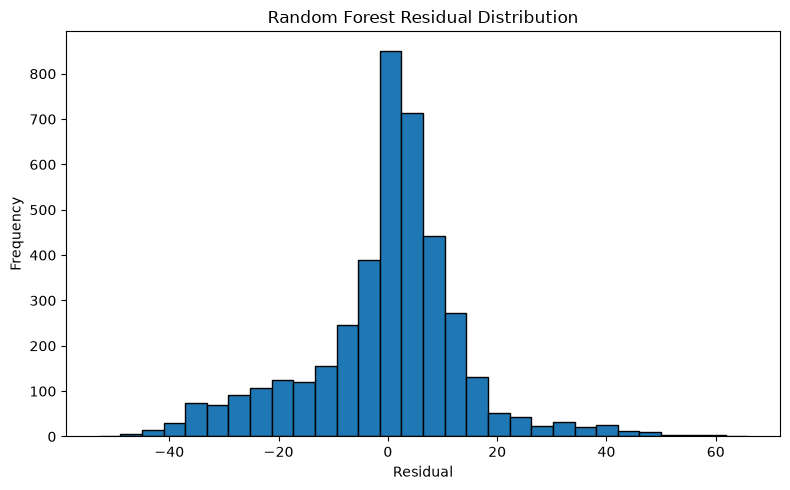

In [62]:
residuals = y_val.to_numpy() - rf_val_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_val_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Random Forest Validation Residuals")
plt.xlabel("Predicted Capped RUL")
plt.ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor="black")
plt.title("Random Forest Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 9. Feature importance

,feature,importance
31,sensor_4_roll_mean_5,0.103654
33,sensor_4_roll_mean_10,0.087354
0,cycle,0.081880
28,sensor_11_roll_mean_10,0.080641
48,sensor_15_roll_mean_10,0.072431
26,sensor_11_roll_mean_5,0.065909
53,sensor_21_roll_mean_10,0.063432
46,sensor_15_roll_mean_5,0.058173
51,sensor_21_roll_mean_5,0.045215
12,sensor_9,0.036873


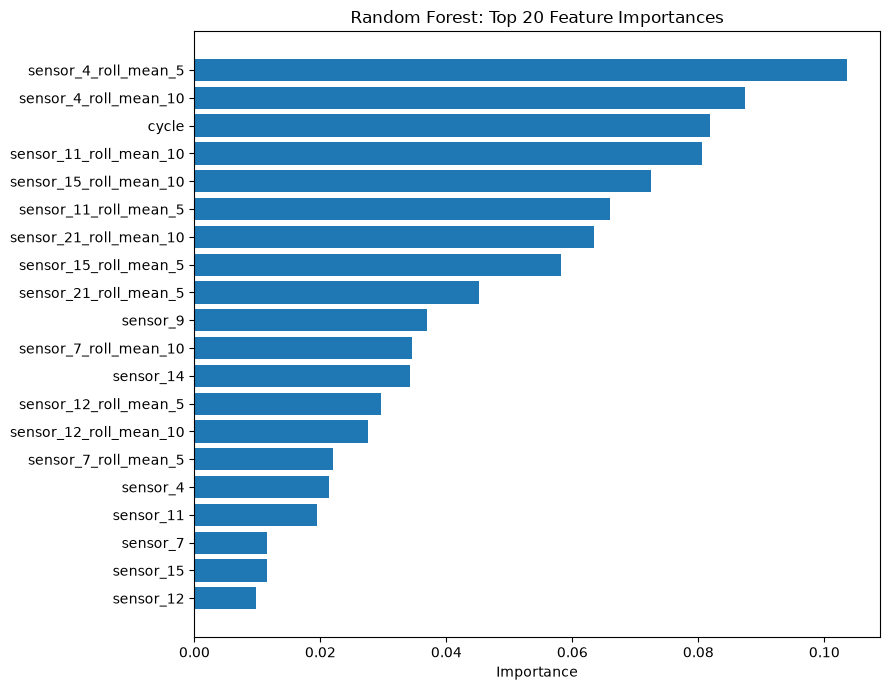

In [63]:
rf_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": rf_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(rf_importance)

plt.figure(figsize=(9, 7))
plt.barh(
    rf_importance["feature"][::-1],
    rf_importance["importance"][::-1]
)
plt.title("Random Forest: Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 10. Retrain on all training engines and evaluate the final test observation

C-MAPSS test ground truth is provided for each engine's last observed cycle.
Therefore, test evaluation uses one row per engine.

In [64]:
test_last_features = (
    test.sort_values(["unit_id", "cycle"])
    .groupby("unit_id", as_index=False)
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

test_eval = test_last_features.merge(
    test_last_truth[["unit_id", "actual_rul"]],
    on="unit_id",
    how="left"
)

X_all = train[feature_cols]
y_all = train[target_col]
X_test_last = test_eval[feature_cols]
y_test = test_eval["actual_rul"]

ridge_pipeline.fit(X_all, y_all)
rf_model.fit(X_all, y_all)

ridge_test_pred = np.clip(ridge_pipeline.predict(X_test_last), 0, None)
rf_test_pred = np.clip(rf_model.predict(X_test_last), 0, None)

test_results = pd.DataFrame([
    evaluate_regression(y_test, ridge_test_pred, "Ridge Regression"),
    evaluate_regression(y_test, rf_test_pred, "Random Forest")
]).sort_values("rmse")

display(test_results)
test_results.to_csv(OUTPUT_DIR / "baseline_test_results.csv", index=False)

,model,rmse,mae,cmapss_score
1,Random Forest,18.629270,13.995013,598.512836
0,Ridge Regression,21.813593,16.904097,1101.315507


NameError: name 'OUTPUT_DIR' is not defined

## 11. Save model predictions

ridge_predictions = pd.DataFrame({
    "unit_id": test_eval["unit_id"],
    "actual_rul": y_test,
    "predicted_rul": ridge_test_pred,
    "model": "Ridge Regression"
})

rf_predictions = pd.DataFrame({
    "unit_id": test_eval["unit_id"],
    "actual_rul": y_test,
    "predicted_rul": rf_test_pred,
    "model": "Random Forest"
})

ridge_predictions.to_csv(
    PREDICTIONS_DIR / "ridge_test_predictions.csv",
    index=False
)
rf_predictions.to_csv(
    PREDICTIONS_DIR / "random_forest_test_predictions.csv",
    index=False
)

display(rf_predictions.head())

## Notebook 02 conclusions

Complete after execution:

- The mean baseline RMSE was ___.
- Ridge Regression achieved ___ RMSE.
- Random Forest achieved ___ RMSE.
- The strongest baseline model was ___.
- The most influential features were ___.

# Part 3 — Advanced ML: XGBoost and Explainability

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PREDICTIONS_DIR = PROJECT_ROOT / "data" / "predictions"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "advanced_ml"

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(PROCESSED_DIR / "fd001_train_processed.csv")
test = pd.read_csv(PROCESSED_DIR / "fd001_test_processed.csv")
test_last_truth = pd.read_csv(PROCESSED_DIR / "fd001_test_last_with_rul.csv")

excluded = {"unit_id", "max_cycle", "rul", "rul_capped", "life_stage"}
feature_cols = [c for c in train.columns if c not in excluded]
target_col = "rul_capped"

print("Features:", len(feature_cols))

## 1. Metrics

In [ ]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def cmapss_score(y_true, y_pred):
    error = np.asarray(y_pred) - np.asarray(y_true)
    penalty = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )
    return float(penalty.sum())

def evaluate(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "rmse": rmse(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "cmapss_score": cmapss_score(y_true, y_pred)
    }

## 2. Engine-level split

In [ ]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    splitter.split(
        train[feature_cols],
        train[target_col],
        groups=train["unit_id"]
    )
)

train_part = train.iloc[train_idx]
val_part = train.iloc[val_idx]

X_train = train_part[feature_cols]
y_train = train_part[target_col]
X_val = val_part[feature_cols]
y_val = val_part[target_col]

print("Training engines:", train_part["unit_id"].nunique())
print("Validation engines:", val_part["unit_id"].nunique())

## 3. Initial XGBoost model

In [ ]:
from xgboost import XGBRegressor

xgb_initial = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

xgb_initial.fit(X_train, y_train)

xgb_val_pred = np.clip(
    xgb_initial.predict(X_val),
    0,
    None
)

xgb_initial_result = evaluate_regression(
    y_val,
    xgb_val_pred,
    "Initial XGBoost"
)

xgb_initial_result

{'model': 'Initial XGBoost',
 'rmse': 14.780371996749766,
 'mae': 9.919706344604492,
 'cmapss_score': 18203.417540550192}

In [ ]:
comparison = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    rf_result,
    xgb_initial_result
]).sort_values("rmse")

comparison.style.format({
    "rmse": "{:.2f}",
    "mae": "{:.2f}",
    "cmapss_score": "{:,.0f}"
})

,model,rmse,mae,cmapss_score
3,Random Forest,14.52,10.10,"16,571"
4,Initial XGBoost,14.78,9.92,"18,203"
2,Ridge Regression,17.62,14.23,"21,123"
1,Linear Regression,17.63,14.23,"21,180"
0,Mean Baseline,41.72,36.93,"1,285,856"


## 4. Modest hyperparameter search

The search is intentionally limited so the project remains feasible. GroupKFold
keeps all rows from a given engine in the same fold.

In [ ]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from xgboost import XGBRegressor

param_distributions = {
    "n_estimators": [300, 500, 700, 900],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07],
    "max_depth": [2, 3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.70, 0.80, 0.90, 1.0],
    "colsample_bytree": [0.70, 0.80, 0.90, 1.0],
    "reg_alpha": [0.0, 0.05, 0.1, 0.2],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0]
}

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

group_cv = GroupKFold(n_splits=3)

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

xgb_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit="rmse",
    cv=group_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

xgb_search.fit(
    X_train,
    y_train,
    groups=train_part["unit_id"]
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'rmse'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These 

In [ ]:
print("Best parameters:")
print(xgb_search.best_params_)

print(
    "Best cross-validation RMSE:",
    -xgb_search.best_score_
)

Best parameters:
{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.05, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Best cross-validation RMSE: 16.455524444580078


In [ ]:
cv_results = pd.DataFrame(
    xgb_search.cv_results_
)

cv_summary = cv_results[
    [
        "params",
        "mean_train_rmse",
        "mean_test_rmse",
        "std_test_rmse",
        "mean_test_mae",
        "std_test_mae",
        "rank_test_rmse"
    ]
].copy()

for column in [
    "mean_train_rmse",
    "mean_test_rmse",
    "mean_test_mae"
]:
    cv_summary[column] = -cv_summary[column]

cv_summary = (
    cv_summary
    .sort_values("rank_test_rmse")
    .reset_index(drop=True)
)

display(cv_summary.head(10))

,params,mean_train_rmse,mean_test_rmse,std_test_rmse,mean_test_mae,std_test_mae,rank_test_rmse
0,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alp...",10.884468,16.455524,1.275062,11.492073,0.730900,1
1,"{'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alp...",8.679535,16.502157,1.280547,11.539631,0.767254,2
2,"{'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alp...",13.786850,16.514190,1.099666,11.687050,0.708000,3
3,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp...",8.783540,16.518627,1.245903,11.554833,0.733127,4
4,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp...",7.043489,16.519125,1.344145,11.461130,0.788230,5
5,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",7.448009,16.526448,1.363342,11.427026,0.820651,6
6,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp...",10.494289,16.536993,1.278051,11.585737,0.759245,7
7,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp...",8.126574,16.566733,1.282181,11.667389,0.777866,8
8,"{'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alp...",10.396572,16.615400,1.213414,11.813627,0.754374,9
9,"{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alp...",3.384189,16.623157,1.304784,11.479578,0.775518,10


In [ ]:
best_xgb = xgb_search.best_estimator_

tuned_xgb_val_pred = np.clip(
    best_xgb.predict(X_val),
    0,
    None
)

tuned_xgb_result = evaluate_regression(
    y_val,
    tuned_xgb_val_pred,
    "Tuned XGBoost"
)

tuned_xgb_result

{'model': 'Tuned XGBoost',
 'rmse': 14.856183115383725,
 'mae': 9.971927642822266,
 'cmapss_score': 17907.825892407996}

In [ ]:
xgb_comparison = pd.DataFrame([
    xgb_initial_result,
    tuned_xgb_result
]).sort_values("rmse")

display(
    xgb_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}"
    })
)

,model,rmse,mae,cmapss_score
0,Initial XGBoost,14.78,9.92,"18,203"
1,Tuned XGBoost,14.86,9.97,"17,908"


In [ ]:
comparison = pd.DataFrame([
    baseline_result,
    linear_result,
    ridge_result,
    rf_result,
    xgb_initial_result,
    tuned_xgb_result
]).sort_values("rmse")

display(
    comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}"
    })
)

,model,rmse,mae,cmapss_score
3,Random Forest,14.52,10.10,"16,571"
4,Initial XGBoost,14.78,9.92,"18,203"
5,Tuned XGBoost,14.86,9.97,"17,908"
2,Ridge Regression,17.62,14.23,"21,123"
1,Linear Regression,17.63,14.23,"21,180"
0,Mean Baseline,41.72,36.93,"1,285,856"


## 5. Validation evaluation

best_xgb = search.best_estimator_
tuned_pred = np.clip(best_xgb.predict(X_val), 0, None)

tuned_result = evaluate(y_val, tuned_pred, "Tuned XGBoost")
comparison = pd.DataFrame([initial_result, tuned_result]).sort_values("rmse")
display(comparison)
comparison.to_csv(OUTPUT_DIR / "xgboost_validation_results.csv", index=False)

## 6. Residual analysis

residuals = y_val.to_numpy() - tuned_pred

plt.figure(figsize=(8, 5))
plt.scatter(tuned_pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title("Tuned XGBoost Validation Residuals")
plt.xlabel("Predicted Capped RUL")
plt.ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()

## 7. Built-in feature importance

importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": best_xgb.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance)

plt.figure(figsize=(9, 7))
plt.barh(importance["feature"][::-1], importance["importance"][::-1])
plt.title("XGBoost: Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. SHAP analysis

SHAP is optional. If it is unavailable, the notebook will continue and the
built-in feature-importance analysis remains valid.

try:
    import shap

    sample_size = min(1500, len(X_val))
    X_shap = X_val.sample(sample_size, random_state=RANDOM_STATE)

    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(
        shap_values,
        X_shap,
        max_display=15,
        show=False
    )
    plt.tight_layout()
    plt.show()

except Exception as exc:
    print("SHAP analysis skipped:", exc)

## Notebook 03 conclusions

Complete after execution:

- Tuned XGBoost achieved validation RMSE of ___.
- Its FD001 test RMSE was ___.
- The most influential features were ___.
- SHAP showed that higher/lower values of ___ tended to increase predicted RUL.
- Compared with Random Forest, XGBoost performed ___.

# Part 4 — Deep Learning: LSTM Sequence Model

In [ ]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.2/111.2 MB 80.5 MB/s  0:00:01eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [torch]32m3/4 [torch]

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [66]:
from pathlib import Path
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

RANDOM_STATE = 42
SEQUENCE_LENGTH = 30
BATCH_SIZE = 256
MAX_EPOCHS = 60
PATIENCE = 8

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

Device: mps


In [67]:
sequence_features = (
    ["setting_1", "setting_2", "setting_3"]
    + metadata["selected_sensors"]
)

In [68]:
scaler = StandardScaler()

scaler.fit(
    train_part[sequence_features]
)

train_part.loc[:, sequence_features] = scaler.transform(
    train_part[sequence_features]
)

val_part.loc[:, sequence_features] = scaler.transform(
    val_part[sequence_features]
)

/var/folders/2r/332z66392pj1l0pjjmkkwjq00000gn/T/ipykernel_5544/1496156265.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.42624592 -0.77952854 -1.42624592 ...  3.1007757   1.16062358
  1.80734095]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_part.loc[:, sequence_features] = scaler.transform(
/var/folders/2r/332z66392pj1l0pjjmkkwjq00000gn/T/ipykernel_5544/1496156265.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.77952854 -0.77952854 -2.07296329 ...  1.80734095  1.80734095
  1.80734095]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  val_part.loc[:, sequence_features] = scaler.transform(


In [69]:
SEQUENCE_LENGTH = 30

def build_train_sequences(
    df,
    features,
    target,
    sequence_length
):
    X = []
    y = []
    unit_ids = []

    for unit_id, engine in df.groupby("unit_id"):
        engine = engine.sort_values("cycle")

        values = engine[
            features
        ].to_numpy(dtype=np.float32)

        targets = engine[
            target
        ].to_numpy(dtype=np.float32)

        if len(engine) < sequence_length:
            continue

        for end in range(
            sequence_length,
            len(engine) + 1
        ):
            start = end - sequence_length

            X.append(values[start:end])
            y.append(targets[end - 1])
            unit_ids.append(unit_id)

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(unit_ids)
    )

In [70]:
X_train_seq, y_train_seq, train_seq_units = build_train_sequences(
    train_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq, val_seq_units = build_train_sequences(
    val_part,
    sequence_features,
    "rul_capped",
    SEQUENCE_LENGTH
)

print("Training sequence shape:", X_train_seq.shape)
print("Validation sequence shape:", X_val_seq.shape)
print("Training target shape:", y_train_seq.shape)
print("Validation target shape:", y_val_seq.shape)

Training sequence shape: (14241, 30, 18)
Validation sequence shape: (3490, 30, 18)
Training target shape: (14241,)
Validation target shape: (3490,)


In [73]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(
            X.astype(np.float32, copy=False)
        )

        self.y = torch.from_numpy(
            y.astype(np.float32, copy=False)
        ).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [74]:
train_dataset = SequenceDataset(
    X_train_seq,
    y_train_seq
)

val_dataset = SequenceDataset(
    X_val_seq,
    y_val_seq
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 14241
Validation dataset: 3490


In [75]:
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 56
Validation batches: 14


In [76]:
print(X_train_seq.dtype)
print(y_train_seq.dtype)

float32
float32


In [77]:
class RULLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
        dropout=0.20
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.regressor(last_hidden)

In [78]:
lstm_model = RULLSTM(
    input_size=len(sequence_features),
    hidden_size=64,
    num_layers=1,
    dropout=0.20
).to(DEVICE)

lstm_criterion = nn.MSELoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print(lstm_model)

RULLSTM(
  (lstm): LSTM(18, 64, batch_first=True)
  (regressor): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [79]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0

    with torch.set_grad_enabled(is_training):

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0
                )

                optimizer.step()

            batch_size = X_batch.size(0)

            total_loss += loss.item() * batch_size
            total_examples += batch_size

    return total_loss / total_examples

In [80]:
MAX_EPOCHS = 60
PATIENCE = 8

lstm_history = {
    "train_loss": [],
    "val_loss": []
}

best_lstm_state = None
best_lstm_val_loss = np.inf
best_lstm_epoch = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = run_epoch(
        lstm_model,
        train_loader,
        lstm_criterion,
        lstm_optimizer
    )

    val_loss = run_epoch(
        lstm_model,
        val_loader,
        lstm_criterion
    )

    lstm_history["train_loss"].append(train_loss)
    lstm_history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train RMSE: {train_loss ** 0.5:.3f} | "
        f"Val RMSE: {val_loss ** 0.5:.3f}"
    )

    if val_loss < best_lstm_val_loss - 1e-4:
        best_lstm_val_loss = val_loss
        best_lstm_state = copy.deepcopy(
            lstm_model.state_dict()
        )
        best_lstm_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("LSTM early stopping triggered.")
        break

lstm_model.load_state_dict(best_lstm_state)

print("Best LSTM epoch:", best_lstm_epoch)
print(
    "Best LSTM validation RMSE:",
    best_lstm_val_loss ** 0.5
)

Epoch 01 | Train RMSE: 89.484 | Val RMSE: 85.114
Epoch 02 | Train RMSE: 81.160 | Val RMSE: 74.698
Epoch 03 | Train RMSE: 69.114 | Val RMSE: 60.957
Epoch 04 | Train RMSE: 54.470 | Val RMSE: 45.408
Epoch 05 | Train RMSE: 38.549 | Val RMSE: 29.279
Epoch 06 | Train RMSE: 25.013 | Val RMSE: 18.471
Epoch 07 | Train RMSE: 18.727 | Val RMSE: 14.960
Epoch 08 | Train RMSE: 16.450 | Val RMSE: 12.918
Epoch 09 | Train RMSE: 15.551 | Val RMSE: 13.166
Epoch 10 | Train RMSE: 14.918 | Val RMSE: 12.944
Epoch 11 | Train RMSE: 14.459 | Val RMSE: 12.678
Epoch 12 | Train RMSE: 14.008 | Val RMSE: 12.662
Epoch 13 | Train RMSE: 13.637 | Val RMSE: 12.757
Epoch 14 | Train RMSE: 13.452 | Val RMSE: 12.418
Epoch 15 | Train RMSE: 13.267 | Val RMSE: 13.401
Epoch 16 | Train RMSE: 13.042 | Val RMSE: 12.895
Epoch 17 | Train RMSE: 13.020 | Val RMSE: 13.045
Epoch 18 | Train RMSE: 13.057 | Val RMSE: 13.028
Epoch 19 | Train RMSE: 12.635 | Val RMSE: 14.415
Epoch 20 | Train RMSE: 13.060 | Val RMSE: 13.101
Epoch 21 | Train RMS

In [82]:
def predict_loader(model, loader, device):
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            batch_predictions = model(X_batch)

            predictions.append(
                batch_predictions.cpu().numpy()
            )
            actuals.append(
                y_batch.numpy()
            )

    predictions = np.concatenate(predictions).ravel()
    actuals = np.concatenate(actuals).ravel()

    return actuals, predictions

In [83]:
y_lstm_val, lstm_val_pred = predict_loader(
    lstm_model,
    val_loader,
    DEVICE
)

# RUL cannot be negative
lstm_val_pred = np.clip(
    lstm_val_pred,
    0,
    None
)

print("Actual shape:", y_lstm_val.shape)
print("Prediction shape:", lstm_val_pred.shape)

Actual shape: (3490,)
Prediction shape: (3490,)


In [84]:
lstm_result = evaluate_regression(
    y_lstm_val,
    lstm_val_pred,
    "LSTM"
)

lstm_result

{'model': 'LSTM',
 'rmse': 12.418345975711135,
 'mae': 9.022809028625488,
 'cmapss_score': 9528.9189453125}

In [86]:
class RULGRU(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
        dropout=0.20
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        output, _ = self.gru(x)
        last_hidden = output[:, -1, :]
        return self.regressor(last_hidden)

In [87]:
gru_model = RULGRU(
    input_size=len(sequence_features),
    hidden_size=64,
    num_layers=1,
    dropout=0.20
).to(DEVICE)

gru_criterion = nn.MSELoss()

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print(gru_model)

RULGRU(
  (gru): GRU(18, 64, batch_first=True)
  (regressor): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [88]:
MAX_EPOCHS = 60
PATIENCE = 8

gru_history = {
    "train_loss": [],
    "val_loss": []
}

best_gru_state = None
best_gru_val_loss = np.inf
best_gru_epoch = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):

    train_loss = run_epoch(
        gru_model,
        train_loader,
        gru_criterion,
        gru_optimizer
    )

    val_loss = run_epoch(
        gru_model,
        val_loader,
        gru_criterion
    )

    gru_history["train_loss"].append(train_loss)
    gru_history["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch:02d} | "
        f"Train RMSE: {train_loss ** 0.5:.3f} | "
        f"Val RMSE: {val_loss ** 0.5:.3f}"
    )

    if val_loss < best_gru_val_loss - 1e-4:
        best_gru_val_loss = val_loss
        best_gru_state = copy.deepcopy(
            gru_model.state_dict()
        )
        best_gru_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("GRU early stopping triggered.")
        break

gru_model.load_state_dict(best_gru_state)

print("Best GRU epoch:", best_gru_epoch)
print(
    "Best GRU validation RMSE:",
    best_gru_val_loss ** 0.5
)

Epoch 01 | Train RMSE: 89.177 | Val RMSE: 85.059
Epoch 02 | Train RMSE: 81.376 | Val RMSE: 76.236
Epoch 03 | Train RMSE: 70.411 | Val RMSE: 63.630
Epoch 04 | Train RMSE: 56.166 | Val RMSE: 48.545
Epoch 05 | Train RMSE: 40.835 | Val RMSE: 33.949
Epoch 06 | Train RMSE: 27.052 | Val RMSE: 18.557
Epoch 07 | Train RMSE: 19.569 | Val RMSE: 15.726
Epoch 08 | Train RMSE: 18.210 | Val RMSE: 15.038
Epoch 09 | Train RMSE: 16.640 | Val RMSE: 13.762
Epoch 10 | Train RMSE: 15.841 | Val RMSE: 12.733
Epoch 11 | Train RMSE: 15.328 | Val RMSE: 12.941
Epoch 12 | Train RMSE: 15.016 | Val RMSE: 14.065
Epoch 13 | Train RMSE: 14.809 | Val RMSE: 12.327
Epoch 14 | Train RMSE: 14.569 | Val RMSE: 12.313
Epoch 15 | Train RMSE: 14.257 | Val RMSE: 13.173
Epoch 16 | Train RMSE: 14.382 | Val RMSE: 13.249
Epoch 17 | Train RMSE: 14.053 | Val RMSE: 12.542
Epoch 18 | Train RMSE: 13.846 | Val RMSE: 13.063
Epoch 19 | Train RMSE: 13.983 | Val RMSE: 13.505
Epoch 20 | Train RMSE: 14.179 | Val RMSE: 12.941
Epoch 21 | Train RMS

In [89]:
y_gru_val, gru_val_pred = predict_loader(
    gru_model,
    val_loader,
    DEVICE
)

gru_val_pred = np.clip(
    gru_val_pred,
    0,
    None
)

gru_result = evaluate_regression(
    y_gru_val,
    gru_val_pred,
    "GRU"
)

gru_result

{'model': 'GRU',
 'rmse': 12.312535319785953,
 'mae': 8.694100379943848,
 'cmapss_score': 10782.470703125}

In [90]:
dl_comparison = pd.DataFrame([
    lstm_result,
    gru_result
]).sort_values(
    ["rmse", "mae"]
).reset_index(drop=True)

display(
    dl_comparison.style.format({
        "rmse": "{:.2f}",
        "mae": "{:.2f}",
        "cmapss_score": "{:,.0f}"
    })
)

,model,rmse,mae,cmapss_score
0,GRU,12.31,8.69,"10,782"
1,LSTM,12.42,9.02,"9,529"
